**EXPERIMENT 7 — Decision Tree & Random Forest**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [10]:
df = pd.read_csv("/content/placement_predict_50k Dataset.csv")
df = df.drop(columns=["IsAnomaly"])

for c in df.columns:
    if pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].fillna(df[c].median())
    else:
        df[c] = df[c].fillna(df[c].mode()[0])

df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=["PlacementStatus"])
y = df["PlacementStatus"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Decision** **Tree**

--> Train decision tree

In [12]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Decision Tree Accuracy: 0.9982
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



--> Visualize tree

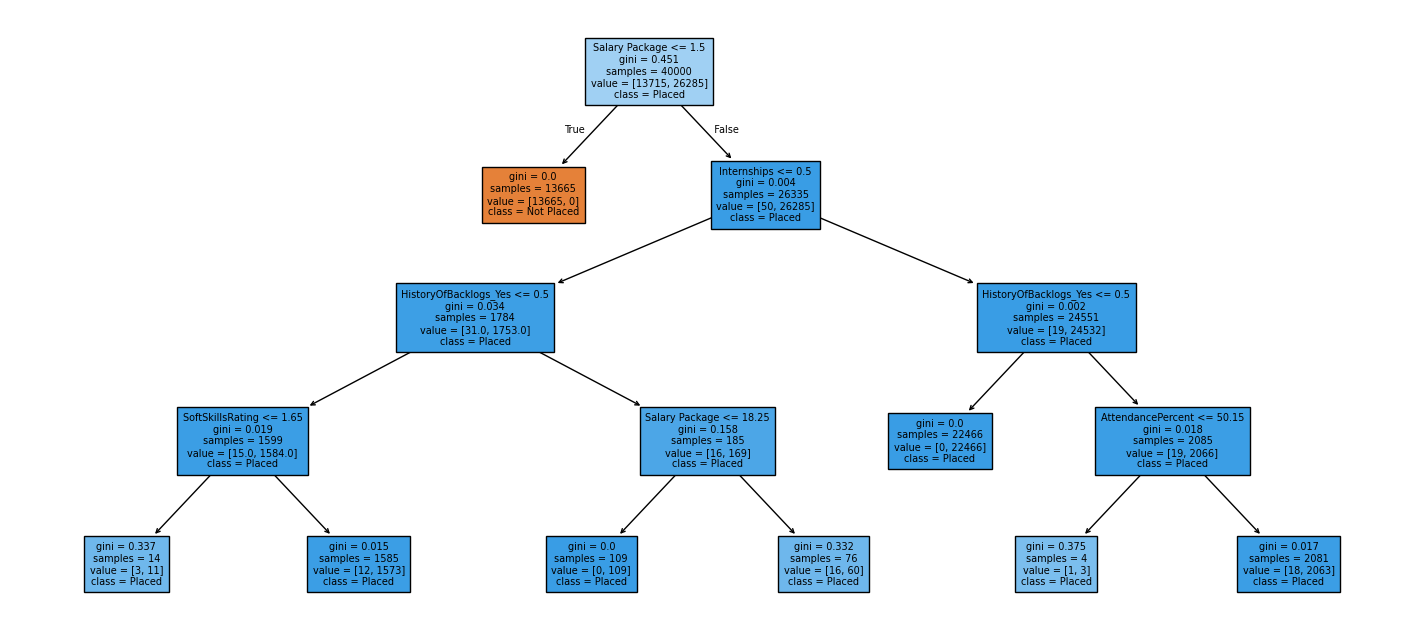

In [13]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=7
)
plt.show()

**Random** **Forest**


--> Train Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("OOB Score:", rf.oob_score_)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9982
OOB Score: 0.998725
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



--> Feature Importance

In [15]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Salary Package                0.409096
SGPA_Sem8                     0.081306
SGPA_Sem7                     0.068424
CGPA_Tier_Low                 0.050386
MockInterviewScore            0.036549
SGPA_Sem4                     0.036451
Projects                      0.030477
SGPA_Sem5                     0.027514
SGPA_Sem1                     0.026522
CodingTestScore               0.026113
CGPA                          0.025730
SGPA_Sem2                     0.025142
SoftSkillsRating              0.024651
SGPA_Sem3                     0.024250
SGPA_Sem6                     0.024050
AptitudeTestScore             0.017062
Internships                   0.014403
Certifications                0.012846
AttendancePercent             0.010255
HistoryOfBacklogs_Yes         0.009152
CollegeTier_Tier3             0.004606
Workshops                     0.003159
StudentID                     0.002420
Publications                  0.002034
CGPA_Tier_Mid                 0.001123
ExtraCurricular          

--> Compare the two models

In [16]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.9982
1,Random Forest,0.9982


**Concepts Covered**


**Decision Tree Classification**
Splitting data using feature conditions
max_depth
Prediction and accuracy
Classification report
Decision tree visualization


**Random Forest Classification**
Ensemble of multiple decision trees
n_estimators
max_features="sqrt"
Bootstrap sampling


**Out-of-Bag (OOB) Score**
Using samples not selected for a particular tree to estimate model performance


**Feature Importance**
Identifying which features contribute most to Random Forest predictions


**Model Comparison**
Comparing Decision Tree vs Random Forest using test accuracy


**Basic Preprocessing**
Missing-value handling
Categorical encoding
Train-test split